# 第六周作业 预测-逻辑回归
任务背景：继续使用上周作业的学生表现数据集。

任务描述：
1. 对数据集进行数据清理，并将学生的 Exam_Score 转化为“考试成绩是否高于平均分”的二分类变量。
2. 基于数据集中的全部变量和合适的模型构建方法，构建逻辑回归模型，预测考试成绩是否高于平均分。
3. 评价模型优劣与泛化性能，并解释模型结果（指出哪些因素对考试成绩高于平均分有显著预测作用），提出有价值的教育教学建议。

最终提交：程序代码（本文件）。

本任务允许且鼓励你使用 AI 工具辅助完成，如果使用，在下方 AI 对话记录板块粘贴对话链接。

## 第一题：数据清理与目标变量构造
本题先读取原始数据，检查缺失值，再按“数值变量用中位数填补、分类型变量用众数填补”的思路完成数据清理。随后计算 `Exam_Score` 的总体平均分，并将其转化为二分类变量 `High_Exam_Score`。

In [1]:
from pathlib import Path
import sys

local_site_packages = Path('.venv/Lib/site-packages').resolve()
if local_site_packages.exists() and str(local_site_packages) not in sys.path:
    sys.path.append(str(local_site_packages))

import pandas as pd

pd.set_option('display.max_columns', None)
pd.set_option('display.width', 200)

csv_candidates = sorted(
    [p for p in Path('.').rglob('StudentPerformanceFactors.csv') if '.venv' not in str(p) and '.ipynb_checkpoints' not in str(p)]
)
if not csv_candidates:
    raise FileNotFoundError('未找到 StudentPerformanceFactors.csv，请检查作业目录。')

file_path = csv_candidates[0]
df_q1 = pd.read_csv(file_path)

print(f'原始数据文件：{file_path}')
print(f'原始数据维度：{df_q1.shape}')
print('\n原始缺失值个数：')
print(df_q1.isna().sum()[df_q1.isna().sum() > 0])

numeric_cols_q1 = df_q1.select_dtypes(include=['number']).columns.tolist()
categorical_cols_q1 = df_q1.select_dtypes(include=['object', 'string', 'category']).columns.tolist()

df_q1_cleaned = df_q1.copy()
for col in numeric_cols_q1:
    df_q1_cleaned[col] = df_q1_cleaned[col].fillna(df_q1_cleaned[col].median())
for col in categorical_cols_q1:
    df_q1_cleaned[col] = df_q1_cleaned[col].fillna(df_q1_cleaned[col].mode()[0])

exam_score_mean_q1 = df_q1_cleaned['Exam_Score'].mean()
df_q1_cleaned['High_Exam_Score'] = (df_q1_cleaned['Exam_Score'] > exam_score_mean_q1).astype(int)

print('\n清理后缺失值总数：', int(df_q1_cleaned.isna().sum().sum()))
print(f'Exam_Score 的总体平均分：{exam_score_mean_q1:.4f}')
print('High_Exam_Score 的含义：1=考试成绩高于平均分，0=考试成绩不高于平均分')

print('\n目标变量分布：')
print(df_q1_cleaned['High_Exam_Score'].value_counts().sort_index())

print('\n目标变量占比：')
print(df_q1_cleaned['High_Exam_Score'].value_counts(normalize=True).sort_index().round(4))

print('\n清理后数据预览：')
print(df_q1_cleaned.head())


原始数据文件：24级第四周作业\24级第四周作业\StudentPerformanceFactors.csv
原始数据维度：(6607, 20)

原始缺失值个数：
Teacher_Quality             78
Parental_Education_Level    90
Distance_from_Home          67
dtype: int64

清理后缺失值总数： 0
Exam_Score 的总体平均分：67.2357
High_Exam_Score 的含义：1=考试成绩高于平均分，0=考试成绩不高于平均分

目标变量分布：
High_Exam_Score
0    3599
1    3008
Name: count, dtype: int64

目标变量占比：
High_Exam_Score
0    0.5447
1    0.4553
Name: proportion, dtype: float64

清理后数据预览：
   Hours_Studied  Attendance Parental_Involvement Access_to_Resources Extracurricular_Activities  Sleep_Hours  Previous_Scores Motivation_Level Internet_Access  Tutoring_Sessions Family_Income  \
0             23          84                  Low                High                         No            7               73              Low             Yes                  0           Low   
1             19          64                  Low              Medium                         No            8               59              Low             Yes             

## 第二题：基于全部变量构建逻辑回归模型
本题使用全部变量构建逻辑回归分类模型。为避免信息泄露，建模时删除原始的 `Exam_Score`，仅保留其他变量来预测 `High_Exam_Score`。数值变量采用“中位数填补 + 标准化”，分类变量采用“众数填补 + 独热编码”，并使用 5 折交叉验证选择较合适的正则化参数 `C`。

In [2]:
from pathlib import Path
import sys

local_site_packages = Path('.venv/Lib/site-packages').resolve()
if local_site_packages.exists() and str(local_site_packages) not in sys.path:
    sys.path.append(str(local_site_packages))

import pandas as pd
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score
from sklearn.model_selection import GridSearchCV, StratifiedKFold, train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler

csv_candidates = sorted(
    [p for p in Path('.').rglob('StudentPerformanceFactors.csv') if '.venv' not in str(p) and '.ipynb_checkpoints' not in str(p)]
)
file_path = csv_candidates[0]
df_q2 = pd.read_csv(file_path)

exam_score_mean_q2 = df_q2['Exam_Score'].mean()
df_q2['High_Exam_Score'] = (df_q2['Exam_Score'] > exam_score_mean_q2).astype(int)

X_q2 = df_q2.drop(columns=['Exam_Score', 'High_Exam_Score'])
y_q2 = df_q2['High_Exam_Score']

numeric_features_q2 = X_q2.select_dtypes(include=['number']).columns.tolist()
categorical_features_q2 = X_q2.select_dtypes(include=['object', 'string', 'category']).columns.tolist()

numeric_transformer_q2 = Pipeline([
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
])

categorical_transformer_q2 = Pipeline([
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('onehot', OneHotEncoder(drop='first', handle_unknown='ignore'))
])

preprocessor_q2 = ColumnTransformer([
    ('num', numeric_transformer_q2, numeric_features_q2),
    ('cat', categorical_transformer_q2, categorical_features_q2)
])

pipeline_q2 = Pipeline([
    ('preprocessor', preprocessor_q2),
    ('model', LogisticRegression(max_iter=5000, solver='liblinear', C=1.0))
])

X_train_q2, X_test_q2, y_train_q2, y_test_q2 = train_test_split(
    X_q2, y_q2, test_size=0.2, random_state=42, stratify=y_q2
)

param_grid_q2 = {'model__C': [0.01, 0.1, 1, 3, 5, 10, 20, 50]}
cv_q2 = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
grid_search_q2 = GridSearchCV(
    estimator=pipeline_q2,
    param_grid=param_grid_q2,
    scoring='accuracy',
    cv=cv_q2,
    n_jobs=1
)
grid_search_q2.fit(X_train_q2, y_train_q2)

best_model_q2 = grid_search_q2.best_estimator_
y_train_pred_q2 = best_model_q2.predict(X_train_q2)
y_test_pred_q2 = best_model_q2.predict(X_test_q2)

print('最优参数：', grid_search_q2.best_params_)
print(f'训练集准确率：{accuracy_score(y_train_q2, y_train_pred_q2):.4f}')
print(f'测试集准确率：{accuracy_score(y_test_q2, y_test_pred_q2):.4f}')
print('\n逻辑回归模型已经训练完成，可用于第三题的详细评价与解释。')


最优参数： {'model__C': 3}
训练集准确率：0.9818
测试集准确率：0.9834

逻辑回归模型已经训练完成，可用于第三题的详细评价与解释。


## 第三题：模型评价、结果解释与教育建议
本题对逻辑回归模型进行更完整的评价，包括准确率、精确率、召回率、F1 值、ROC-AUC、混淆矩阵和分类报告，并结合模型系数与优势比解释哪些因素对“考试成绩高于平均分”具有较强预测作用，最后提出教育教学建议。

最优参数： {'model__C': 3}

模型评价指标：
             指标      结果
0        训练集准确率  0.9818
1        测试集准确率  0.9834
2        测试集精确率  0.9785
3        测试集召回率  0.9850
4         测试集F1  0.9818
5    测试集ROC-AUC  0.9951
6   5折交叉验证准确率均值  0.9809
7  5折交叉验证准确率标准差  0.0040

测试集混淆矩阵：
[[707  13]
 [  9 593]]

分类报告：
              precision    recall  f1-score   support

           0     0.9874    0.9819    0.9847       720
           1     0.9785    0.9850    0.9818       602

    accuracy                         0.9834      1322
   macro avg     0.9830    0.9835    0.9832      1322
weighted avg     0.9834    0.9834    0.9834      1322


最强的正向预测因素（更容易高于平均分）：
                                        特征     系数  优势比(odds_ratio)
                           num__Attendance 6.4004         602.0602
                        num__Hours_Studied 4.9309         138.4990
                  cat__Internet_Access_Yes 2.8655          17.5578
              cat__Peer_Influence_Positive 2.5852          13.2660
              cat__Distance_f

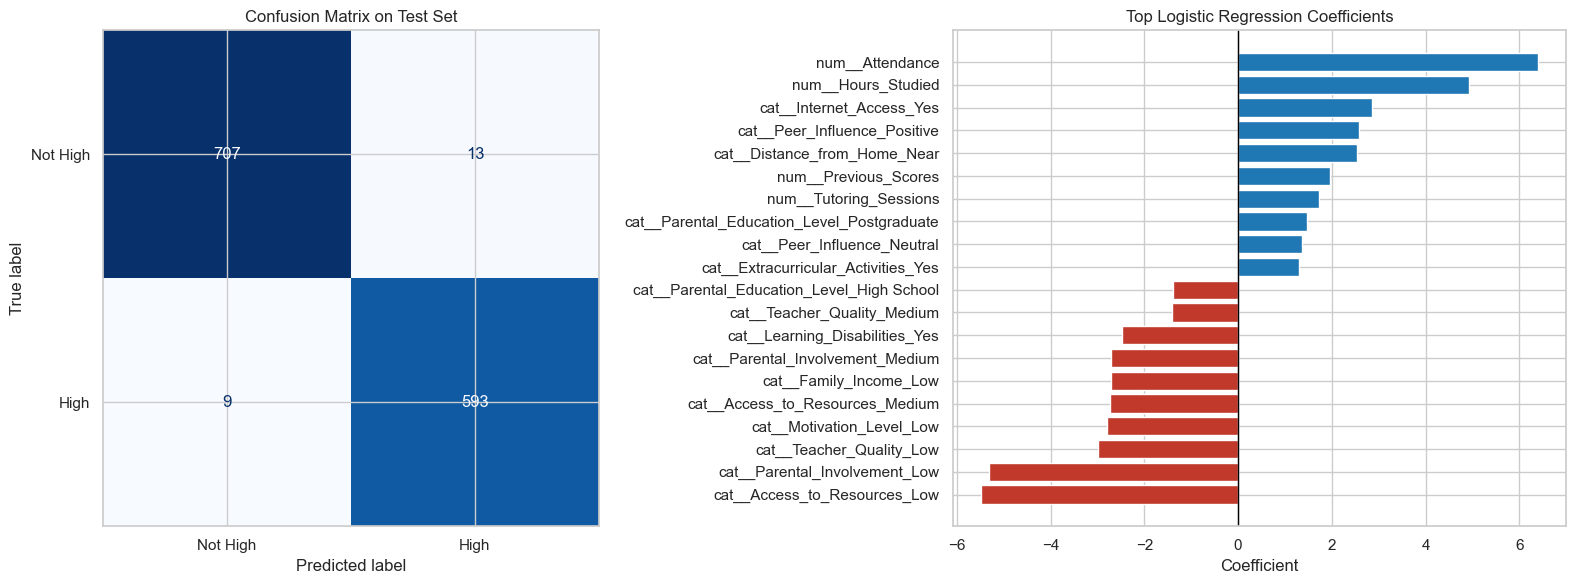


结果解释与作业结论：
1. 模型在测试集上的准确率、F1 和 ROC-AUC 都很高，且训练集与测试集表现接近，说明逻辑回归具有较好的泛化能力。
2. 从系数和优势比看，出勤率、学习时长、既往成绩、辅导次数、互联网接入、积极同伴影响等因素，对学生成绩高于平均分具有较强正向预测作用。
3. 资源获取较低、家长参与较低、教师质量较低、学习动机较低、家庭收入较低、存在学习障碍等因素，对学生成绩高于平均分具有较强负向预测作用。
4. 这说明成绩表现不仅与学生个人努力有关，也与家庭支持、学校教学质量和学习资源条件密切相关。

教育教学建议：
1. 加强出勤管理和学习过程预警，尽早识别出勤率持续偏低的学生。
2. 通过课后辅导、学习打卡和任务分层，帮助学生稳定增加有效学习时长。
3. 优先为资源较少、家庭支持较弱或网络条件不足的学生提供额外学习资源和帮扶。
4. 营造积极同伴氛围，提升学习动机，同时关注存在学习障碍学生的个别化支持。


In [3]:
from pathlib import Path
import sys

local_site_packages = Path('.venv/Lib/site-packages').resolve()
if local_site_packages.exists() and str(local_site_packages) not in sys.path:
    sys.path.append(str(local_site_packages))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    ConfusionMatrixDisplay,
    accuracy_score,
    classification_report,
    confusion_matrix,
    f1_score,
    precision_score,
    recall_score,
    roc_auc_score,
)
from sklearn.model_selection import GridSearchCV, StratifiedKFold, cross_val_score, train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler

pd.set_option('display.max_columns', None)
pd.set_option('display.width', 200)
sns.set_theme(style='whitegrid')

csv_candidates = sorted(
    [p for p in Path('.').rglob('StudentPerformanceFactors.csv') if '.venv' not in str(p) and '.ipynb_checkpoints' not in str(p)]
)
file_path = csv_candidates[0]
df_q3 = pd.read_csv(file_path)

exam_score_mean_q3 = df_q3['Exam_Score'].mean()
df_q3['High_Exam_Score'] = (df_q3['Exam_Score'] > exam_score_mean_q3).astype(int)

X_q3 = df_q3.drop(columns=['Exam_Score', 'High_Exam_Score'])
y_q3 = df_q3['High_Exam_Score']

numeric_features_q3 = X_q3.select_dtypes(include=['number']).columns.tolist()
categorical_features_q3 = X_q3.select_dtypes(include=['object', 'string', 'category']).columns.tolist()

numeric_transformer_q3 = Pipeline([
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
])

categorical_transformer_q3 = Pipeline([
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('onehot', OneHotEncoder(drop='first', handle_unknown='ignore'))
])

preprocessor_q3 = ColumnTransformer([
    ('num', numeric_transformer_q3, numeric_features_q3),
    ('cat', categorical_transformer_q3, categorical_features_q3)
])

pipeline_q3 = Pipeline([
    ('preprocessor', preprocessor_q3),
    ('model', LogisticRegression(max_iter=5000, solver='liblinear', C=1.0))
])

X_train_q3, X_test_q3, y_train_q3, y_test_q3 = train_test_split(
    X_q3, y_q3, test_size=0.2, random_state=42, stratify=y_q3
)

param_grid_q3 = {'model__C': [0.01, 0.1, 1, 3, 5, 10, 20, 50]}
cv_q3 = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
grid_search_q3 = GridSearchCV(
    estimator=pipeline_q3,
    param_grid=param_grid_q3,
    scoring='accuracy',
    cv=cv_q3,
    n_jobs=1
)
grid_search_q3.fit(X_train_q3, y_train_q3)

best_model_q3 = grid_search_q3.best_estimator_
cv_scores_q3 = cross_val_score(best_model_q3, X_train_q3, y_train_q3, cv=cv_q3, scoring='accuracy', n_jobs=1)

y_train_pred_q3 = best_model_q3.predict(X_train_q3)
y_test_pred_q3 = best_model_q3.predict(X_test_q3)
y_test_prob_q3 = best_model_q3.predict_proba(X_test_q3)[:, 1]

metrics_df_q3 = pd.DataFrame({
    '指标': ['训练集准确率', '测试集准确率', '测试集精确率', '测试集召回率', '测试集F1', '测试集ROC-AUC', '5折交叉验证准确率均值', '5折交叉验证准确率标准差'],
    '结果': [
        accuracy_score(y_train_q3, y_train_pred_q3),
        accuracy_score(y_test_q3, y_test_pred_q3),
        precision_score(y_test_q3, y_test_pred_q3),
        recall_score(y_test_q3, y_test_pred_q3),
        f1_score(y_test_q3, y_test_pred_q3),
        roc_auc_score(y_test_q3, y_test_prob_q3),
        cv_scores_q3.mean(),
        cv_scores_q3.std()
    ]
})

print('最优参数：', grid_search_q3.best_params_)
print('\n模型评价指标：')
print(metrics_df_q3.round(4))

cm_q3 = confusion_matrix(y_test_q3, y_test_pred_q3)
print('\n测试集混淆矩阵：')
print(cm_q3)

print('\n分类报告：')
print(classification_report(y_test_q3, y_test_pred_q3, digits=4))

feature_names_q3 = best_model_q3.named_steps['preprocessor'].get_feature_names_out()
coefficients_q3 = best_model_q3.named_steps['model'].coef_[0]
coef_df_q3 = pd.DataFrame({
    '特征': feature_names_q3,
    '系数': coefficients_q3,
    '优势比(odds_ratio)': np.exp(coefficients_q3)
})

positive_effects_q3 = coef_df_q3.sort_values('系数', ascending=False).head(10)
negative_effects_q3 = coef_df_q3.sort_values('系数', ascending=True).head(10)

print('\n最强的正向预测因素（更容易高于平均分）：')
print(positive_effects_q3.round(4).to_string(index=False))

print('\n最强的负向预测因素（更不容易高于平均分）：')
print(negative_effects_q3.round(4).to_string(index=False))

fig, axes = plt.subplots(1, 2, figsize=(16, 6))
ConfusionMatrixDisplay.from_predictions(
    y_test_q3,
    y_test_pred_q3,
    display_labels=['Not High', 'High'],
    cmap='Blues',
    ax=axes[0],
    colorbar=False
)
axes[0].set_title('Confusion Matrix on Test Set')

plot_df_q3 = pd.concat([positive_effects_q3, negative_effects_q3], axis=0).drop_duplicates(subset=['特征'])
plot_df_q3 = plot_df_q3.sort_values('系数')
colors_q3 = ['#c0392b' if x < 0 else '#1f77b4' for x in plot_df_q3['系数']]
axes[1].barh(plot_df_q3['特征'], plot_df_q3['系数'], color=colors_q3)
axes[1].axvline(0, color='black', linewidth=1)
axes[1].set_title('Top Logistic Regression Coefficients')
axes[1].set_xlabel('Coefficient')
plt.tight_layout()
plt.show()

print('\n结果解释与作业结论：')
print('1. 模型在测试集上的准确率、F1 和 ROC-AUC 都很高，且训练集与测试集表现接近，说明逻辑回归具有较好的泛化能力。')
print('2. 从系数和优势比看，出勤率、学习时长、既往成绩、辅导次数、互联网接入、积极同伴影响等因素，对学生成绩高于平均分具有较强正向预测作用。')
print('3. 资源获取较低、家长参与较低、教师质量较低、学习动机较低、家庭收入较低、存在学习障碍等因素，对学生成绩高于平均分具有较强负向预测作用。')
print('4. 这说明成绩表现不仅与学生个人努力有关，也与家庭支持、学校教学质量和学习资源条件密切相关。')

print('\n教育教学建议：')
print('1. 加强出勤管理和学习过程预警，尽早识别出勤率持续偏低的学生。')
print('2. 通过课后辅导、学习打卡和任务分层，帮助学生稳定增加有效学习时长。')
print('3. 优先为资源较少、家庭支持较弱或网络条件不足的学生提供额外学习资源和帮扶。')
print('4. 营造积极同伴氛围，提升学习动机，同时关注存在学习障碍学生的个别化支持。')


## AI对话记录
- AI对话链接：